#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import joblib
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Set results path

In [4]:
results_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res'

#Functions

In [5]:
def get_r2_mse_rmse_plot_pred(data_y_test, model_predictions, model_type):

  r2 = r2_score(data_y_test, model_predictions)
  mse = mean_squared_error(data_y_test, model_predictions)
  rmse = mse**0.5

  print(f"R-squared: {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")


  plt.figure(figsize=(8, 6))
  for i in range(data_y_test.shape[1]):
      plt.scatter(data_y_test.iloc[:, i], model_predictions[:, i], alpha=0.5)

  plt.plot([data_y_test.min().min(), data_y_test.max().max()], [data_y_test.min().min(), data_y_test.max().max()], 'k--', lw=2, label='Ideal')

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"Predicted vs. Actual Values for Metabolites ({model_type})")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
  plt.grid(True)
  plt.savefig(f'{results_path}/{model_type}.svg', bbox_inches = 'tight')
  plt.show()

In [6]:
def plot_cv_scores(model_pipeline, model_type, cv_fold):

    # Impute missing values in 'rna' before cross-validation
    imputer_rna = SimpleImputer(strategy='mean')  # Use the same strategy as for metabolites
    rna_imputed = imputer_rna.fit_transform(rna)
    rna_imputed = pd.DataFrame(rna_imputed, columns=rna.columns, index=rna.index)

    imputer_metabolites = SimpleImputer(strategy='mean')
    metabolites_imputed = imputer_metabolites.fit_transform(metabolites)
    metabolites_imputed = pd.DataFrame(metabolites_imputed, columns=metabolites.columns, index=metabolites.index)

    model_1_preds = model_1.predict(rna_imputed)
    model_2_preds = model_2.predict(rna_imputed)

    stacked_features_train = np.hstack([model_1_preds, model_2_preds])

    # Use the imputed 'rna' data for cross-validation
    scores = cross_val_score(model_pipeline, stacked_features_train, metabolites_imputed, cv=cv_fold, scoring='neg_mean_squared_error', n_jobs=-1)

    print("Cross-validation scores:", scores)
    print("Average score:", scores.mean())

    scores = pd.DataFrame(scores)
    scores = scores.rename(columns={0: 'Cross-validation scores'})
    scores['Cross-validation fold'] = [i + 1 for i in range(len(scores))]

    sns.lineplot(data=scores, x='Cross-validation fold', y='Cross-validation scores')
    plt.ylabel('Negative MSE')
    plt.title('Negative MSE fluctuation with CV-fold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(f'{results_path}/MSE vs CV ({model_type}).svg', bbox_inches='tight')
    plt.show()

In [7]:
def get_r2_cross_val(model, model_name):
  cv = KFold(n_splits=10, shuffle=True, random_state=0)

  # Impute missing values in X_train before cross-validation
  imputer = SimpleImputer(strategy='mean')  # or any other suitable strategy
  X_train_imputed = imputer.fit_transform(X_train)

  model_1_preds = model_1.predict(X_train_imputed)
  model_2_preds = model_2.predict(X_train_imputed)

  stacked_features_train = np.hstack([model_1_preds, model_2_preds])

  # Use the imputed data for cross-validation
  scores = cross_val_score(model, stacked_features_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

  print("Cross-validation R-squared scores:", scores)
  print("Average R-squared score:", scores.mean())

  scores_df = pd.DataFrame({'Fold': range(1, len(scores) + 1), 'R-squared': scores})

  # Plot the scores
  plt.figure(figsize=(8, 6))
  sns.lineplot(x='Fold', y='R-squared', data=scores_df, marker='o')
  plt.title(f'Cross-validation R-squared scores for {model_name}')
  plt.xlabel('Fold')
  plt.ylabel('R-squared')
  plt.savefig(f'{results_path}/R2 vs CV ({model_name}).svg', bbox_inches='tight')
  plt.show()

In [8]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  rmse = mean_squared_error(y_test, y_predicted)
  print("RMSE:", rmse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [9]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions, model_name):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  plt.savefig(f'{results_path}/Spearmans Corr ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [10]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions, model_name):

  residuals = (y_test - model_predictions).values.ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values ({model_name})")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  plt.savefig(f'{results_path}/Residuals vs Pred Values ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [11]:
def plot_r2_per_metabolite(model, model_name, X_test, y_test, model_1, model_2):
    """Plots the R2 score per metabolite for a given model in descending order."""

    # Impute missing values in X_test before prediction
    imputer = SimpleImputer(strategy='mean')
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    model_1_preds_test = model_1.predict(X_test_imputed)
    model_2_preds_test = model_2.predict(X_test_imputed)
    stacked_features_test = np.hstack([model_1_preds_test, model_2_preds_test])

    y_pred = model.predict(stacked_features_test)

    r2_scores = []
    for i in range(y_test.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])
    plt.xticks()
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()
    plt.savefig(f'{results_path}/R2 per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [12]:
def get_r2_per_metabolite(model, model_name, X_test, y_test):
    """Get the R2 score per metabolite for a given model in descending order."""

    # Impute missing values in X_test before prediction
    imputer = SimpleImputer(strategy='mean')
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    model_1_preds_test = model_1.predict(X_test_imputed)
    model_2_preds_test = model_2.predict(X_test_imputed)
    stacked_features_test = np.hstack([model_1_preds_test, model_2_preds_test])

    y_pred = model.predict(stacked_features_test)

    r2_scores = []
    for i in range(y_test.shape[1]):
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])
        r2_scores.append(r2)

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    return r2_df

In [13]:
from scipy.stats import spearmanr

def plot_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""
    imputer = SimpleImputer(strategy='mean') # or any other suitable strategy
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    model_1_preds_test = model_1.predict(X_test_imputed)
    model_2_preds_test = model_2.predict(X_test_imputed)
    stacked_features_test = np.hstack([model_1_preds_test, model_2_preds_test])

    y_pred = model.predict(stacked_features_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    plt.savefig(f'{results_path}/Spearman per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [14]:
def get_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Get the Spearman's correlation coefficient per metabolite for a given model."""
    imputer = SimpleImputer(strategy='mean') # or any other suitable strategy
    X_test_imputed = imputer.fit_transform(X_test)

    # Generate predictions using the base models and stack them
    model_1_preds_test = model_1.predict(X_test_imputed)
    model_2_preds_test = model_2.predict(X_test_imputed)
    stacked_features_test = np.hstack([model_1_preds_test, model_2_preds_test])

    y_pred = model.predict(stacked_features_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    return spearman_df

In [15]:
def save_model(model, model_name):
    joblib.dump(model, f'{results_path}/{model_name}.pkl')

#Import data

In [16]:
rna = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_transcriptomics_tpm_metabolism_related_genes.csv', index_col = 0 )
rna

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
ACH-000358,1.625081,6.696166,7.161072,1.782253,5.110691,3.412770,6.241274,4.595374,1.607993,0.158358,...,9.858383,-0.005746,-0.009275,1.068180,0.000394,6.210562,4.740603,-0.007723,5.556855,5.312199
ACH-000423,0.073437,6.552783,6.348634,0.926233,3.074971,2.313297,6.781158,4.316389,0.683654,0.420848,...,7.747192,0.009853,-0.033136,0.983597,0.000394,5.430171,4.146615,-0.007723,5.003959,4.437186
ACH-000305,0.499719,4.346704,4.842416,2.827733,3.520762,2.488910,7.007866,4.093062,0.019389,0.222997,...,7.072976,0.040593,0.124745,1.270915,0.000394,3.857106,3.499179,-0.007723,4.831581,4.125357
ACH-000115,0.411982,5.889181,6.002387,2.269233,1.945067,2.137013,7.076125,3.648721,1.794568,-0.048879,...,6.958943,0.009853,0.002481,0.067278,0.024525,6.512522,1.802112,0.830438,5.502801,3.839334
ACH-000405,0.742069,5.504427,7.110944,3.054234,4.288493,1.640858,5.579747,5.599207,0.046655,-0.048879,...,8.240958,-0.005746,-0.033136,3.655740,0.000394,5.689351,1.490951,0.006466,4.913972,3.419875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000811,0.434514,5.157236,6.213981,3.464166,4.427626,1.306580,8.081318,4.883930,0.125358,0.167814,...,7.642639,-0.005746,-0.033136,0.257307,0.000394,5.492344,5.183442,0.806472,5.269029,4.139043
ACH-000772,1.507352,6.120417,6.577882,2.782841,2.370805,2.090823,6.818736,4.955908,4.048804,0.195731,...,9.484702,-0.005746,-0.033136,-0.006798,0.082842,5.755398,4.129259,-0.007723,5.291604,3.879158
ACH-000430,0.122459,6.299095,5.123218,3.072351,2.596416,1.437062,7.264023,4.525830,0.019389,0.465484,...,8.355572,0.009853,-0.033136,0.218541,0.000394,5.292577,6.694022,-0.007723,4.052474,5.055180
ACH-000957,1.479221,5.741245,7.315123,3.562145,3.056095,0.939990,6.675417,4.234586,0.019389,0.805090,...,8.838993,-0.005746,0.092611,0.205396,0.000394,5.790387,3.374747,0.034427,4.785368,4.691053


In [17]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_metabolites.csv', index_col = 0)
metabolites

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,5.923737,5.641242,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,5.760784,5.914742,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,5.742613,5.570208,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,6.342703,6.054781,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,5.871600,5.128463,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000655,5.977636,6.026483,6.480536,6.112056,5.878324,5.732508,5.981183,6.459139,5.642855,6.039198,...,5.547818,5.703861,5.581725,5.506887,5.362247,5.322091,5.556126,5.544802,4.897559,5.506999
ACH-000273,5.957233,6.090834,5.323475,6.145795,5.741201,5.605435,6.184192,6.004195,5.663866,5.758910,...,5.713210,5.651439,5.720680,5.387960,5.275798,5.289684,5.494241,5.533795,5.139488,5.452544
ACH-000504,5.967707,5.931487,5.620542,5.955261,5.935244,5.384674,5.955886,6.239657,5.527619,5.973401,...,5.605403,5.317500,5.630315,5.433324,5.330957,5.481404,5.570553,5.146598,5.010639,5.114385
ACH-000825,5.962415,5.992640,6.296222,5.916386,6.043984,5.883976,5.954731,6.181054,5.820966,6.045409,...,5.949798,6.249271,6.248746,6.130000,5.873297,5.826041,5.997694,6.411166,6.105394,6.387275


In [18]:
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
metabolites

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,5.923737,5.641242,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,5.760784,5.914742,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,5.742613,5.570208,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,6.342703,6.054781,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,5.871600,5.128463,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000655,5.977636,6.026483,6.480536,6.112056,5.878324,5.732508,5.981183,6.459139,5.642855,6.039198,...,5.547818,5.703861,5.581725,5.506887,5.362247,5.322091,5.556126,5.544802,4.897559,5.506999
ACH-000273,5.957233,6.090834,5.323475,6.145795,5.741201,5.605435,6.184192,6.004195,5.663866,5.758910,...,5.713210,5.651439,5.720680,5.387960,5.275798,5.289684,5.494241,5.533795,5.139488,5.452544
ACH-000504,5.967707,5.931487,5.620542,5.955261,5.935244,5.384674,5.955886,6.239657,5.527619,5.973401,...,5.605403,5.317500,5.630315,5.433324,5.330957,5.481404,5.570553,5.146598,5.010639,5.114385
ACH-000825,5.962415,5.992640,6.296222,5.916386,6.043984,5.883976,5.954731,6.181054,5.820966,6.045409,...,5.949798,6.249271,6.248746,6.130000,5.873297,5.826041,5.997694,6.411166,6.105394,6.387275


#Remove outliers

In [19]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

def remove_outliers_isolationforest(data, contamination=0.05):
    """Removes outliers using Isolation Forest."""

    # Handle missing values before applying Isolation Forest
    imputer = SimpleImputer(strategy='mean')  # You can use 'median' or another strategy
    data_clean = imputer.fit_transform(data)

    iso = IsolationForest(contamination=contamination)
    yhat = iso.fit_predict(data_clean)
    filtered_data = data[yhat != -1]  # -1 indicates outliers
    return filtered_data

# Apply to your data
filtered_rna = remove_outliers_isolationforest(rna)
filtered_metabolites = remove_outliers_isolationforest(metabolites)

In [20]:
rna = filtered_rna
metabolites = filtered_metabolites

In [21]:
rna

,GPT,GUSB,NDUFA7,MAN2B2,CYB5R4,NT5M,CERS2,TENT2,GLYATL2,SLC5A2,...,FABP5,CYP4A22,THEM5,PDE6G,ACER1,ENOPH1,ATP2B4,UGT2B11,NAA60,MTAP
ACH-000423,0.073437,6.552783,6.348634,0.926233,3.074971,2.313297,6.781158,4.316389,0.683654,0.420848,...,7.747192,0.009853,-0.033136,0.983597,0.000394,5.430171,4.146615,-0.007723,5.003959,4.437186
ACH-000305,0.499719,4.346704,4.842416,2.827733,3.520762,2.488910,7.007866,4.093062,0.019389,0.222997,...,7.072976,0.040593,0.124745,1.270915,0.000394,3.857106,3.499179,-0.007723,4.831581,4.125357
ACH-000115,0.411982,5.889181,6.002387,2.269233,1.945067,2.137013,7.076125,3.648721,1.794568,-0.048879,...,6.958943,0.009853,0.002481,0.067278,0.024525,6.512522,1.802112,0.830438,5.502801,3.839334
ACH-000405,0.742069,5.504427,7.110944,3.054234,4.288493,1.640858,5.579747,5.599207,0.046655,-0.048879,...,8.240958,-0.005746,-0.033136,3.655740,0.000394,5.689351,1.490951,0.006466,4.913972,3.419875
ACH-000923,1.453660,7.329353,7.351328,3.737804,3.968879,2.149078,6.432907,5.277146,0.033089,0.737697,...,9.097212,-0.005746,-0.033136,0.307502,0.012519,6.080101,4.631199,-0.007723,5.083528,4.197929
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000811,0.434514,5.157236,6.213981,3.464166,4.427626,1.306580,8.081318,4.883930,0.125358,0.167814,...,7.642639,-0.005746,-0.033136,0.257307,0.000394,5.492344,5.183442,0.806472,5.269029,4.139043
ACH-000772,1.507352,6.120417,6.577882,2.782841,2.370805,2.090823,6.818736,4.955908,4.048804,0.195731,...,9.484702,-0.005746,-0.033136,-0.006798,0.082842,5.755398,4.129259,-0.007723,5.291604,3.879158
ACH-000430,0.122459,6.299095,5.123218,3.072351,2.596416,1.437062,7.264023,4.525830,0.019389,0.465484,...,8.355572,0.009853,-0.033136,0.218541,0.000394,5.292577,6.694022,-0.007723,4.052474,5.055180
ACH-000957,1.479221,5.741245,7.315123,3.562145,3.056095,0.939990,6.675417,4.234586,0.019389,0.805090,...,8.838993,-0.005746,0.092611,0.205396,0.000394,5.790387,3.374747,0.034427,4.785368,4.691053


#Data shuffling

In [22]:
combined_data = pd.concat([rna, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_rna = shuffled_data[rna.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

rna = shuffled_rna
metabolites = shuffled_metabolites

#Log2 transformation

In [23]:
#CCLE data are already log2 transformed
# rna = rna.apply(lambda x: np.log2(x + 1))
# rna.head(3)

#Splitting data

In [24]:
metabolites = metabolites.dropna(axis=1, how='all')
metabolites

,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
ACH-000077,5.458940,6.069382,6.877274,6.068750,5.505403,5.933708,5.984277,6.040722,6.683792,5.538999,...,6.245231,6.339022,6.719602,6.448586,6.265289,6.207153,5.872111,6.768072,6.479443,6.610730
ACH-000695,5.896787,5.562469,5.495570,6.198133,5.405480,5.647883,6.114095,5.692338,6.151681,5.689639,...,6.475107,6.162490,6.232128,6.004562,5.941130,5.736837,5.568404,6.366693,6.189653,6.355080
ACH-000056,6.474690,5.993355,5.898925,6.234996,5.175458,6.551271,6.229653,5.676013,6.380704,4.740652,...,6.668476,6.507782,6.815606,6.908637,6.072243,5.822894,5.887173,6.756707,6.739452,6.803388
ACH-000254,5.877068,5.841777,5.741915,6.114489,5.861887,5.882597,5.529294,5.805831,5.679536,5.785007,...,6.037238,6.365852,6.260933,6.235391,6.003001,5.894052,5.403724,6.417076,6.351978,6.248313
ACH-000249,5.649287,5.193497,6.107827,6.195966,5.798423,6.007679,5.718421,5.245186,6.109056,5.669253,...,6.043088,6.548307,5.975254,5.889028,5.986023,5.985538,6.214225,6.312500,6.349744,6.276177
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-000420,5.716054,6.052596,5.981950,5.661450,6.089479,5.989280,5.854356,6.094894,5.710253,5.997358,...,5.951251,5.678187,5.670237,5.564005,5.664185,6.204560,6.118202,5.995632,5.631775,5.635726
ACH-000186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACH-000458,5.948661,5.608500,5.718798,6.242761,5.883056,5.421822,6.014476,5.857438,5.509896,5.833054,...,5.806946,6.387171,6.294858,6.087991,6.086228,5.847084,5.810157,6.368625,6.513523,6.298162
ACH-000015,6.063566,5.872749,5.810142,5.391883,5.919230,5.782723,5.526771,6.020350,6.058400,5.811531,...,5.770202,6.322393,6.400964,6.614755,6.331404,6.035271,5.693780,6.465314,6.290222,6.359597


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(rna, metabolites, test_size=0.2, random_state=0)

In [26]:
from sklearn.impute import SimpleImputer

In [27]:
imputer_train = SimpleImputer(strategy='mean')
y_train_imputed = imputer_train.fit_transform(y_train)

In [28]:
imputer_test = SimpleImputer(strategy='mean')
y_test_imputed = imputer_test.fit_transform(y_test)

In [29]:
y_train = pd.DataFrame(y_train_imputed, columns=y_train.columns, index=y_train.index)
y_test = pd.DataFrame(y_test_imputed, columns=y_test.columns, index=y_test.index)

In [30]:
if y_train.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [31]:
if y_test.isnull().any().any():
    print("DataFrame contains NaN values")
else:
    print("DataFrame does not contain NaN values")

DataFrame does not contain NaN values


In [32]:
y_train_features = y_train.columns
y_train_features

Index(['2-aminoadipate', '3-phosphoglycerate', 'alpha-glycerophosphate',
       '4-pyridoxate', 'aconitate', 'adenine', 'adipate',
       'alpha-ketoglutarate', 'AMP', 'citrate',
       ...
       'C56:8 TAG', 'C56:7 TAG', 'C56:6 TAG', 'C56:5 TAG', 'C56:4 TAG',
       'C56:3 TAG', 'C56:2 TAG', 'C58:8 TAG', 'C58:7 TAG', 'C58:6 TAG'],
      dtype='object', length=225)

#Ensemble training

In [33]:
'''
Ensemble architecture:

base models: elastic net + random forest regressor
final estimator: ridge regression

'''

'\nEnsemble architecture:\n\nbase models: elastic net + random forest regressor\nfinal estimator: ridge regression\n\n'

In [34]:
model_1 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/ElasticNet.pkl')

In [35]:
model_2 = joblib.load('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/CCLE_res/Random Forest Regressor.pkl')

In [36]:
model_1_preds = model_1.predict(X_train)
model_2_preds = model_2.predict(X_train)

stacked_features_train = np.hstack([model_1_preds, model_2_preds])

In [37]:
param_grid = {'alpha': [0.1, 1, 2, 4, 6, 8, 10, 50, 100, 110, 125, 130, 140, 150, 175, 200]}

ridge = Ridge(random_state = 0)
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(stacked_features_train, y_train)

final_estimator = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

model_1_preds_test = model_1.predict(X_test)
model_2_preds_test = model_2.predict(X_test)

stacked_features_test = np.hstack([model_1_preds_test, model_2_preds_test])
y_pred = final_estimator.predict(stacked_features_test)

Best hyperparameters: {'alpha': 2}
Best score: -0.04747630624219793


In [38]:
save_model(model = final_estimator, model_name = 'Ensemble')

#Model assessment

R-squared: 0.6522003539154986
Mean Squared Error (MSE): 0.04680406496379831
Root Mean Squared Error (RMSE): 0.21634247147473912


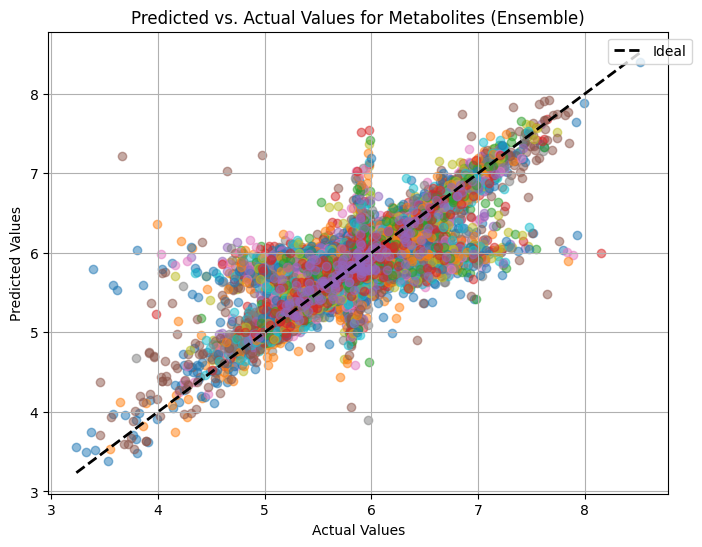

In [39]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = y_pred, model_type = 'Ensemble')

Cross-validation scores: [-0.03825931 -0.04209037 -0.0447121  -0.05134265 -0.0390144  -0.04519336
 -0.04779961 -0.04756143 -0.05097176 -0.04721636]
Average score: -0.04541613639550776


<ipython-input-6-522b2b44710e>:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


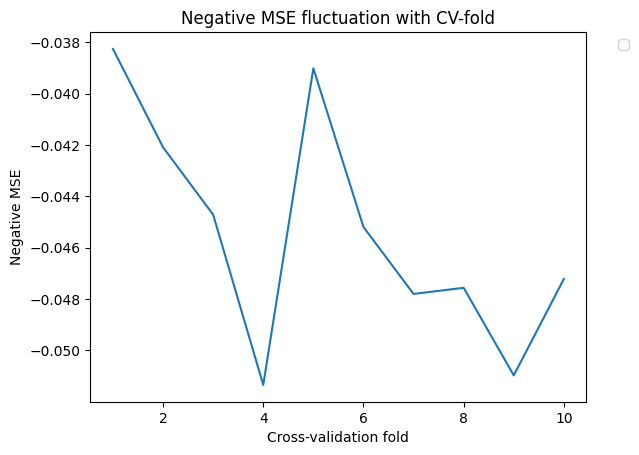

In [40]:
plot_cv_scores(model_pipeline = final_estimator, model_type = 'Ensemble', cv_fold = 10)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


Cross-validation R-squared scores: [0.66071633 0.59915504 0.74470884 0.61238948 0.62846733 0.63388675
 0.62485307 0.67775251 0.56614198 0.65450414]
Average R-squared score: 0.6402575465587956


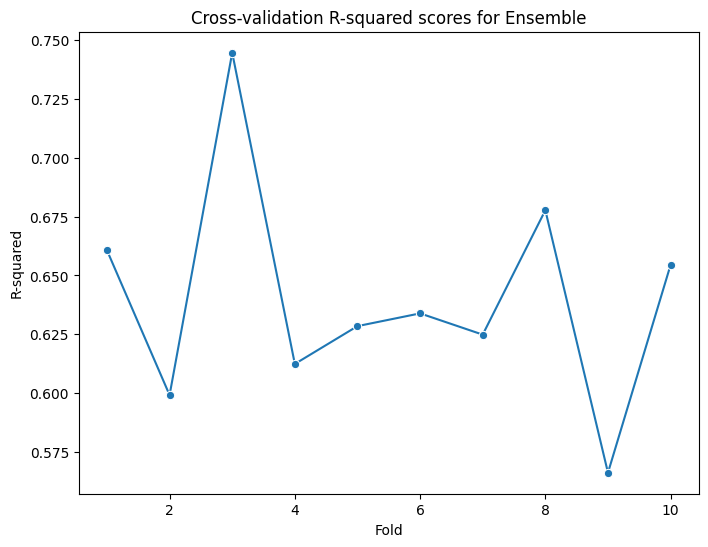

In [41]:
get_r2_cross_val(model = final_estimator, model_name = 'Ensemble')

In [42]:
get_metrics(y_predicted = y_pred)

RMSE: 0.04680406496379831
MAE: 0.13448934291997897
MedAE: 0.08598768828797018
Mean absolute percentage error: 2.3174744733762833


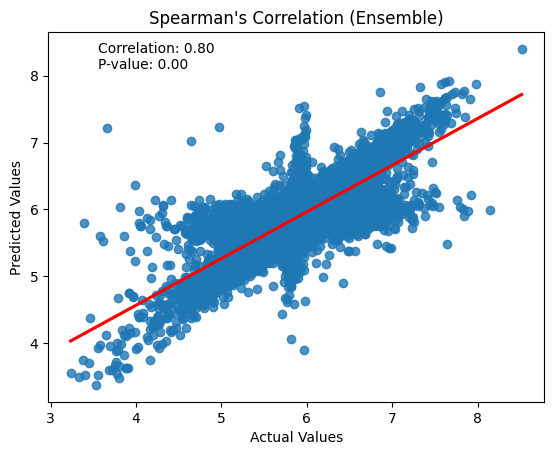

In [43]:
get_spearman_correlation(model_predictions = y_pred, model_name = 'Ensemble')

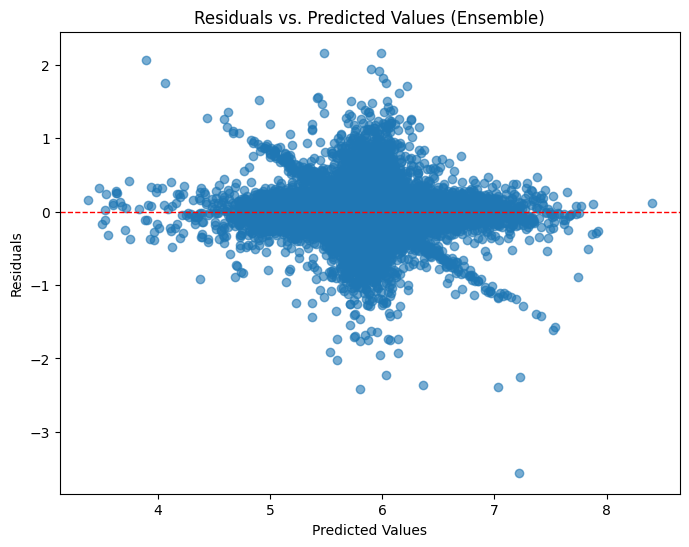

In [44]:
get_residuals_vs_pred_plot(model_predictions = y_pred, model_name = 'Ensemble')

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


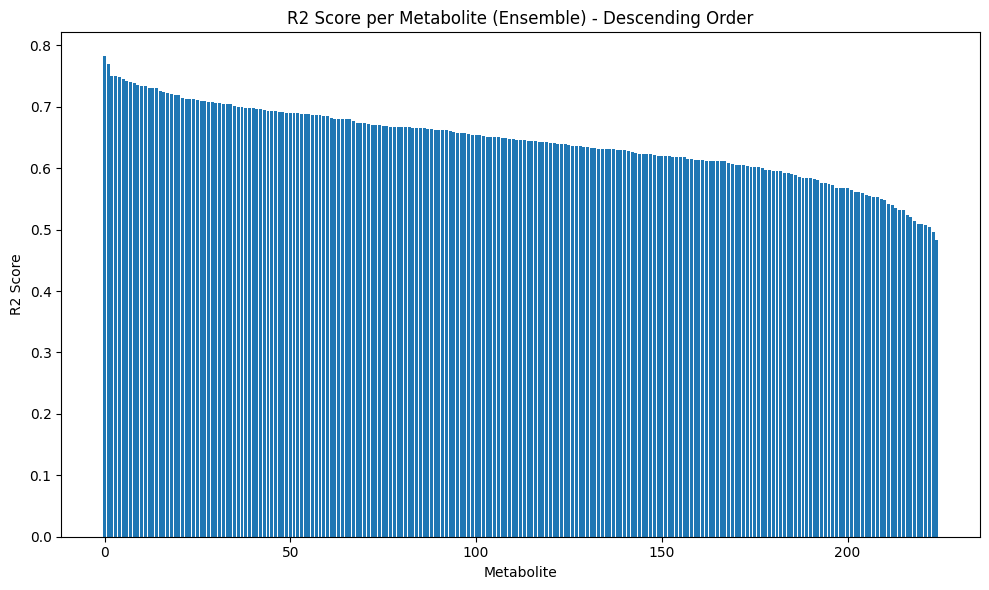

In [45]:
plot_r2_per_metabolite(final_estimator, "Ensemble", X_test, y_test, model_1, model_2)

In [46]:
r2_ensemble = get_r2_per_metabolite(final_estimator, 'Ensemble', X_test, y_test)
r2_ensemble

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


,Metabolite,R2 Score
192,C46:2 TAG,0.782053
195,C48:3 TAG,0.769218
193,C46:1 TAG,0.750395
196,C48:2 TAG,0.750036
110,2-deoxycytidine,0.747744
...,...,...
16,erythrose-4-phosphate,0.508380
58,glycine,0.507129
41,thymine,0.504240
17,F1P/F6P/G1P/G6P,0.496734


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


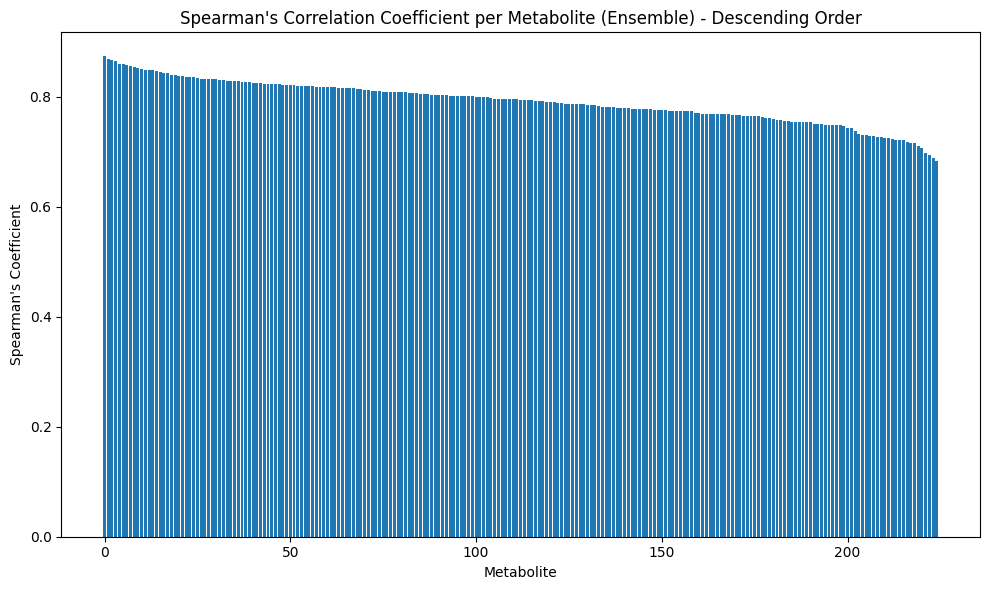

In [47]:
plot_spearman_per_metabolite(final_estimator, 'Ensemble', X_test, y_test)

In [48]:
spearman_ensemble = get_spearman_per_metabolite(final_estimator, 'Ensemble', X_test, y_test)
spearman_ensemble

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


,Metabolite,Spearman Coefficient
193,C46:1 TAG,0.872912
192,C46:2 TAG,0.869088
197,C48:1 TAG,0.866862
94,N-carbamoyl-beta-alanine,0.864118
196,C48:2 TAG,0.859883
...,...,...
98,choline,0.706205
126,heptanoylcarnitine,0.698262
6,adipate,0.694193
167,C14:0 SM,0.688589


In [49]:
r2_ensemble.to_csv(f'{results_path}/r2_ensemble.csv', index = False)
spearman_ensemble.to_csv(f'{results_path}/spearman_ensemble.csv', index = False)